
========== CUSTOMER DASHBOARD ==========

  customer_id  purchase_frequency  total_spent  avg_order_value  \
0     C000001                   2         1200            600.0   
1     C000002                   2         1000            500.0   
2     C000003                   1          300            300.0   
3     C000004                   1          900            900.0   

   website_visits  loyalty_score  churn_flag  
0            22.5           80.0           0  
1            32.5           95.0           0  
2            10.0           40.0           1  
3            40.0           70.0           1  

========== KPI SUMMARY ==========

Total Revenue : 3400
Total Customers : 4
Average Loyalty Score : 71.25
Churn Rate : 50.0 %


<>:16: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:16: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\At\AppData\Local\Temp\ipykernel_19156\467056544.py:16: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['customer_key'] = df['customer_id'].str.extract('(\d+)').astype(int)


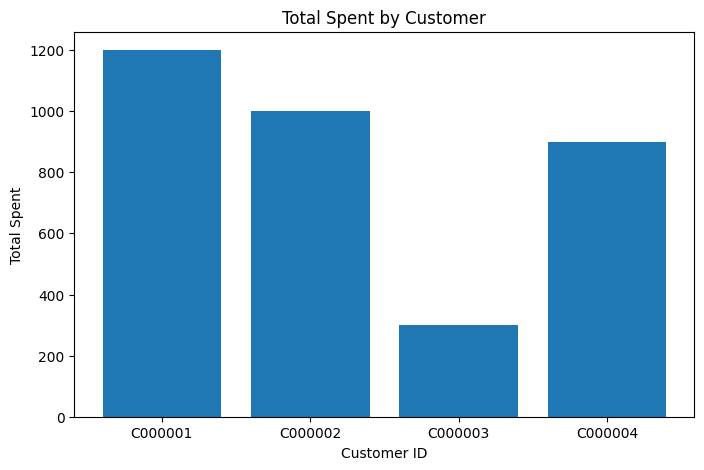

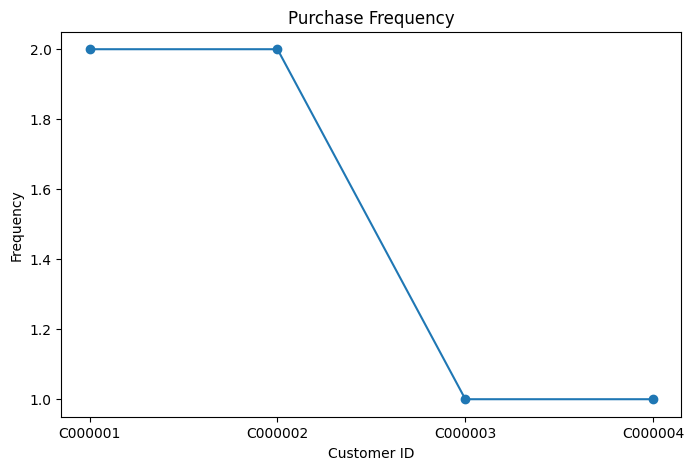

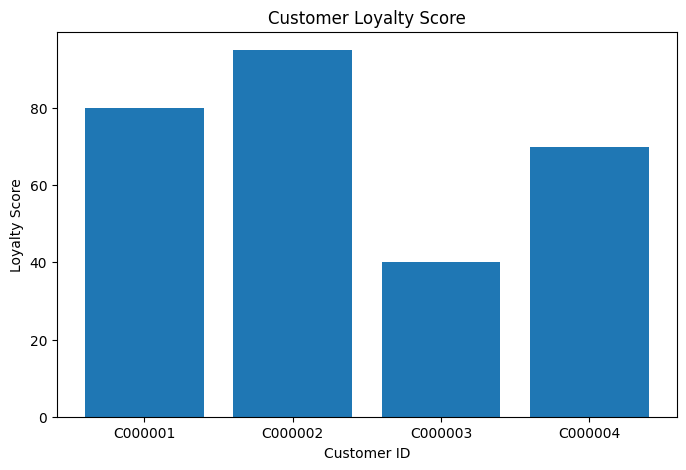

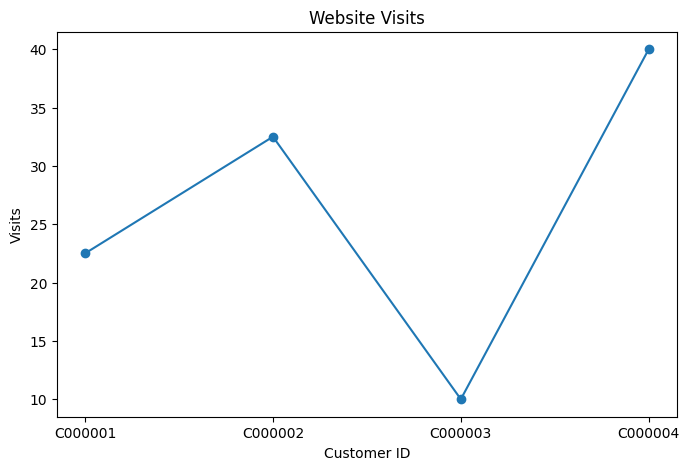

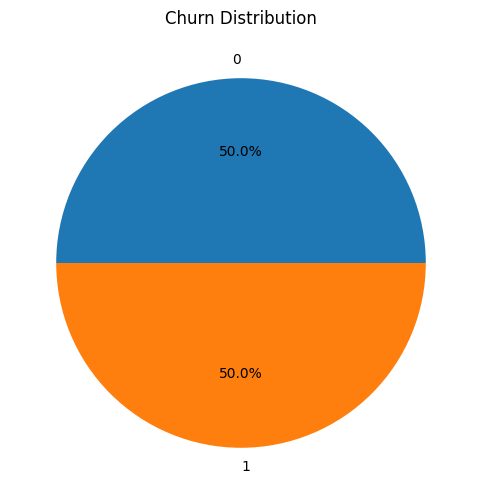

,order_value,website_visits,loyalty_score,churn_flag,customer_key
count,6.000000,6.000000,6.000000,6.000000,6.000000
mean,566.666667,26.666667,76.666667,0.333333,2.166667
std,280.475786,10.801234,20.412415,0.516398,1.169045
min,200.000000,10.000000,40.000000,0.000000,1.000000
25%,350.000000,21.250000,72.500000,0.000000,1.250000
50%,600.000000,27.500000,80.000000,0.000000,2.000000
75%,775.000000,33.750000,91.250000,0.750000,2.750000
max,900.000000,40.000000,95.000000,1.000000,4.000000


In [26]:


import pandas as pd
import matplotlib.pyplot as plt



df = pd.DataFrame({
    'customer_id': ['C000001','C000002','C000003','C000001','C000002','C000004'],
    'order_value': [500,800,300,700,200,900],
    'region': ['North','South','East','North','South','West'],
    'website_visits': [20,35,10,25,30,40],
    'loyalty_score': [80,95,40,80,95,70],
    'churn_flag': [0,0,1,0,0,1]
})


df['customer_key'] = df['customer_id'].str.extract('(\d+)').astype(int)



purchase_frequency = df.groupby('customer_id').size().reset_index(name='purchase_frequency')



total_spent = df.groupby('customer_id')['order_value'].sum().reset_index(name='total_spent')



avg_order_value = df.groupby('customer_id')['order_value'].mean().reset_index(name='avg_order_value')



website_visits = df.groupby('customer_id')['website_visits'].mean().reset_index()



loyalty = df.groupby('customer_id')['loyalty_score'].mean().reset_index()



churn = df.groupby('customer_id')['churn_flag'].max().reset_index()


dashboard = purchase_frequency.merge(total_spent, on='customer_id')
dashboard = dashboard.merge(avg_order_value, on='customer_id')
dashboard = dashboard.merge(website_visits, on='customer_id')
dashboard = dashboard.merge(loyalty, on='customer_id')
dashboard = dashboard.merge(churn, on='customer_id')


print("\n========== CUSTOMER DASHBOARD ==========\n")
print(dashboard)



total_revenue = dashboard['total_spent'].sum()
total_customers = dashboard['customer_id'].nunique()
avg_loyalty = dashboard['loyalty_score'].mean()
churn_rate = dashboard['churn_flag'].mean() * 100

print("\n========== KPI SUMMARY ==========\n")
print("Total Revenue :", total_revenue)
print("Total Customers :", total_customers)
print("Average Loyalty Score :", round(avg_loyalty,2))
print("Churn Rate :", round(churn_rate,2), "%")


plt.figure(figsize=(8,5))
plt.bar(dashboard['customer_id'], dashboard['total_spent'])
plt.title("Total Spent by Customer")
plt.xlabel("Customer ID")
plt.ylabel("Total Spent")
plt.show()



plt.figure(figsize=(8,5))
plt.plot(dashboard['customer_id'], dashboard['purchase_frequency'], marker='o')
plt.title("Purchase Frequency")
plt.xlabel("Customer ID")
plt.ylabel("Frequency")
plt.show()



plt.figure(figsize=(8,5))
plt.bar(dashboard['customer_id'], dashboard['loyalty_score'])
plt.title("Customer Loyalty Score")
plt.xlabel("Customer ID")
plt.ylabel("Loyalty Score")
plt.show()



plt.figure(figsize=(8,5))
plt.plot(dashboard['customer_id'], dashboard['website_visits'], marker='o')
plt.title("Website Visits")
plt.xlabel("Customer ID")
plt.ylabel("Visits")
plt.show()



plt.figure(figsize=(6,6))
dashboard['churn_flag'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.ylabel("")
plt.show()

df.describe()

In [27]:
import streamlit as st
import pandas as pd
import plotly.express as px


df = pd.DataFrame({
    'customer_id': ['C000001','C000002','C000003','C000004'],
    'total_spent': [1200,1000,300,900],
    'purchase_frequency': [2,2,1,1],
    'loyalty_score': [80,95,40,70],
    'website_visits': [25,30,10,40]
})



st.title("Customer Analytics Dashboard")


col1, col2, col3 = st.columns(3)

col1.metric("Total Customers", len(df))
col2.metric("Total Revenue", df['total_spent'].sum())
col3.metric("Avg Loyalty", round(df['loyalty_score'].mean(),2))


fig1 = px.bar(
    df,
    x='customer_id',
    y='total_spent',
    title='Total Spending'
)

st.plotly_chart(fig1)



fig2 = px.line(
    df,
    x='customer_id',
    y='purchase_frequency',
    markers=True,
    title='Purchase Frequency'
)

st.plotly_chart(fig2)



fig3 = px.bar(
    df,
    x='customer_id',
    y='loyalty_score',
    title='Loyalty Score'
)

st.plotly_chart(fig3)



fig4 = px.area(
    df,
    x='customer_id',
    y='website_visits',
    title='Website Visits'
)

st.plotly_chart(fig4)



st.dataframe(df)

2026-05-15 11:28:46.778 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 11:28:46.780 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 11:28:46.781 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 11:28:46.782 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 11:28:46.783 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 11:28:46.784 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 11:28:46.785 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 11:28:46.787 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [28]:
import pandas as pd

data = [10, 12, 13, 15, 18, 100]

df = pd.DataFrame(data, columns=['Values'])

print(df)

df.isnull().sum()
df.duplicated().sum()
df.describe()
# df.corr()

   Values
0      10
1      12
2      13
3      15
4      18
5     100


,Values
count,6.000000
mean,28.000000
std,35.377959
min,10.000000
25%,12.250000
50%,14.000000
75%,17.250000
max,100.000000
